In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

data = np.loadtxt("FAK.txt", skiprows=1)
t = data[:, 0]
x = data[:, 1]
dt = 8.494e-4#[s] 

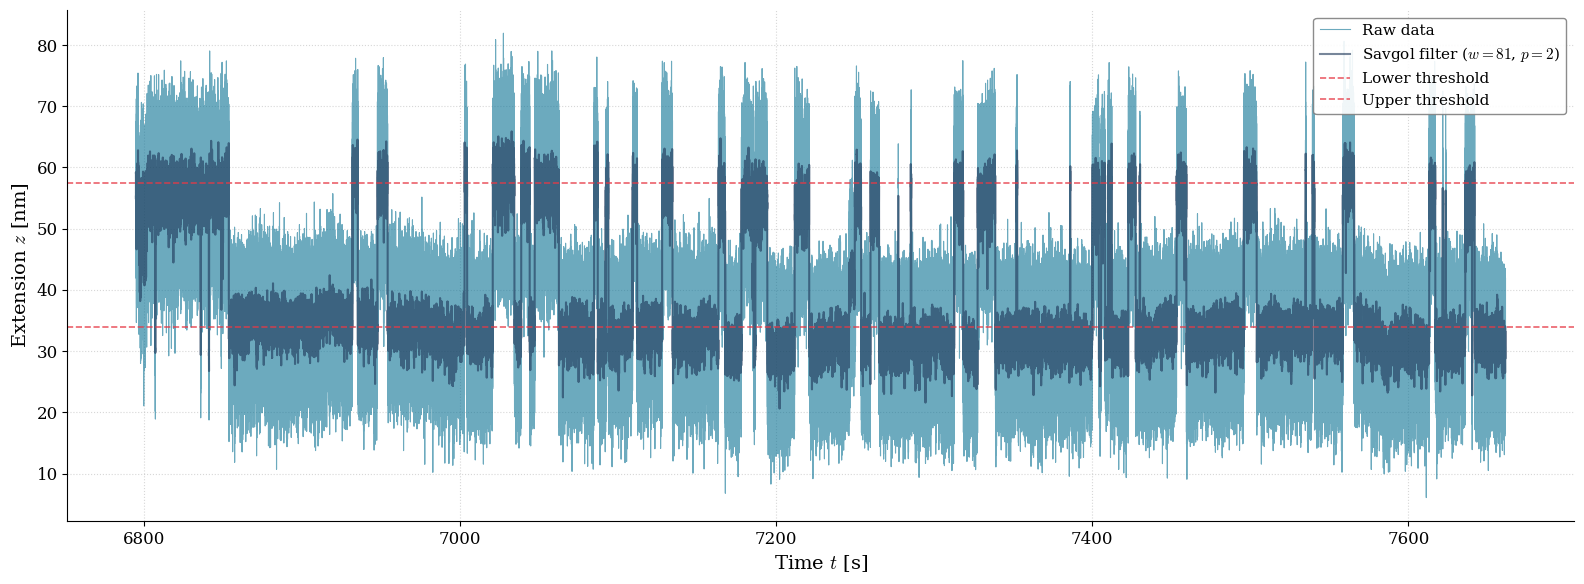

In [ ]:
# SAVITSKY GOLAY 
# ## Instead of averaging values in a window like a moving average, Savitzky-Golay fits a polynomial to the values and evaluates it at the center.

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'mathtext.fontset': 'cm'
})

p, q = 8_000_000, 9_020_000
x_smooth = savgol_filter(x, window_length=81, polyorder=2)

fig, ax = plt.subplots(figsize=(16, 6)) 

ax.plot(t[p:q], x[p:q], color="#0A7294", lw=0.8, alpha=0.6, label="Raw data")
ax.plot(t[p:q], x_smooth[p:q], color='#1D3557', alpha=0.6, lw=1.5, label="Savgol filter ($w=81$, $p=2$)")
ax.axhline(y=34, color='#E63946', linestyle='--', lw=1.2, alpha=0.8, label="Lower threshold")
ax.axhline(y=57.5, color='#E63946', linestyle='--', lw=1.2, alpha=0.8, label="Upper threshold")

ax.set_xlabel("Time $t$ [s]")
ax.set_ylabel("Extension $z$ [nm]")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("FAK_smoothing.pdf", dpi=300)
plt.show()

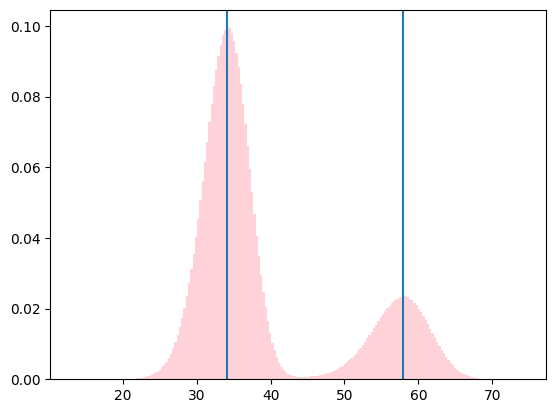

In [ ]:
plt.hist(x_smooth, bins = 200, density = True, alpha = 0.7, color="pink")
m,n = [34.1429672, 57.94641481]
plt.axvline(x = m); plt.axvline(x= n)



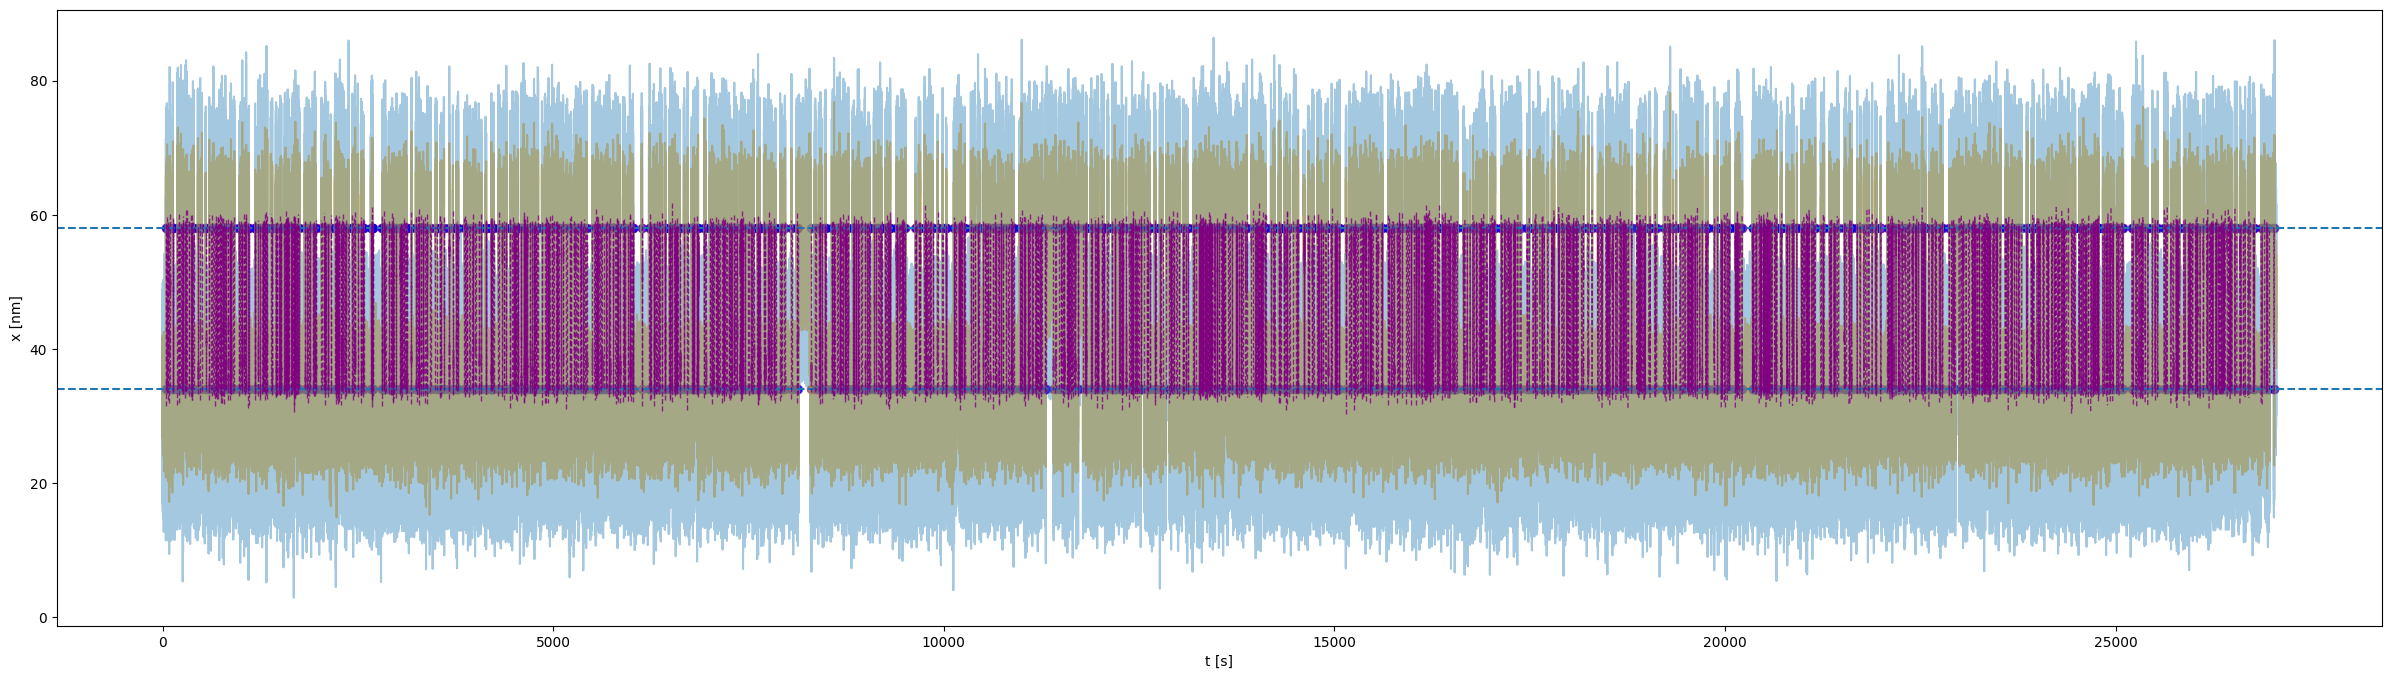

In [ ]:
d_detrend = np.load("x_detrend_FAK.npy")
x_smooth = savgol_filter(d_detrend, window_length = 21, polyorder =2)

# applico filtro TRANSIZIONI 
mask = np.full_like(x_smooth, np.nan)
mask[x_smooth < 34.2] = 34
mask[x_smooth > 57.9] = 58

start = 0
fine  = int(2/3 * len(x))
t_win = t[start:fine]
x_win = x_smooth[start:fine]
mask_win  = mask[start:fine]

valid_idx   = np.where(~np.isnan(mask_win))[0]      # array di indici
valid_vals  = mask_win[valid_idx]       
change_pos  = np.where(valid_vals[1:] != valid_vals[:-1])[0] + 1

# Considera solo transizioni tra 34 e 58
v1 = valid_vals[change_pos - 1]
v2 = valid_vals[change_pos]
is_transition = ((v1 == 34) & (v2 == 58)) | ((v1 == 58) & (v2 == 34))

change_pos = change_pos[is_transition]

idx_from = valid_idx[change_pos - 1]    # ultimo indice del blocco corrente
idx_to   = valid_idx[change_pos]        # primo indice del blocco successivo


plt.figure(figsize=(30, 8))
plt.scatter(t_win[idx_to], mask_win[idx_to], c='red', s=35, alpha = 0.5)
plt.scatter(t_win[idx_from], mask_win[idx_from], c='blue', s=35, alpha =0.5)
plt.plot(t_win, x_smooth[start:fine], color='orange', alpha=0.6)
plt.plot(t_win, d_detrend[start:fine], label = "raw data", alpha=0.4)
plt.axhline(y = 58, linestyle="--"); plt.axhline(y= 34, linestyle="--")

x_detrend = np.full_like(x_win, np.nan)
start = 0



offset = 0

# PLOT TRANSIZIONI 
for i_from, i_to in zip(idx_from, idx_to):
    i_start = max(i_from - offset, 0)
    i_end   = min(i_to   + offset, fine-1)
    plt.plot(t_win[i_start:i_end+1], x_win[i_start:i_end+1], color='purple', lw=1, alpha=.8, linestyle='--')
plt.xlabel('t [s]'); plt.ylabel('x [nm]')
plt.show()

# print(f'Numero di transizioni rilevate: {len(idx_from)}')
# # idx_from  = ultimo indice del plateau corrente   (30 o 68)
# # idx_to    = primo indice del plateau successivo (68 o 30)

# # PRINT TRANSITIONS
# for k, (i_from, i_to) in enumerate(zip(idx_from, idx_to), start=1):
#     print(f"Salto #{k:02d}:  from idx {i_from }  →  to idx {i_to}, len: {i_to - i_from}")

# # # # # # Costruzione dati
# data = []
# for i, (i_from, i_to) in enumerate(zip(idx_from, idx_to)):
#     dt = t_win[i_to] - t_win[i_from]
#     transition_type = 'unfolding' if i % 2 == 0 else 'folding'
#     data.append((i_from, i_to, dt, transition_type, t_win[i_from], t_win[i_to]))

# df = pd.DataFrame(data, columns=["start_idx", "end_idx", "duration", "type", "t_1", "t_2"])
# df.to_pickle("fak_errorPT.pkl")



In [693]:
# check TRANSITIONS PATH 
df = pd.read_pickle("fak_errorPT.pkl")
df

# talin: 0.0008 sec sampling rate 

# FAK : 0.00084

# # selezioni transizioni > 0.4 sec 
# df_meta = df[(df["duration"] > 0.04) & (df["duration"] < 0.067)]

# a = df_meta[df_meta["type"]=="folding"]
# df_meta["n_idx"] = df_meta["end_idx"] - df_meta["start_idx"]
# df_meta
# np.mean(df_meta["n_idx"])


,start_idx,end_idx,duration,type,t_1,t_2
0,49902,49917,0.012737,unfolding,42.386162,42.398899
1,51512,51536,0.020385,folding,43.753674,43.774059
2,61265,61276,0.009346,unfolding,52.037754,52.047100
3,67732,67753,0.017838,folding,57.530746,57.548584
4,86430,86445,0.012741,unfolding,73.412605,73.425346
...,...,...,...,...,...,...
2440,31717481,31717491,0.010000,unfolding,26940.447000,26940.457000
2441,31725083,31725101,0.016000,folding,26946.904000,26946.920000
2442,31749400,31749412,0.011000,unfolding,26967.559000,26967.570000
2443,31817325,31817342,0.014000,folding,27025.254000,27025.268000


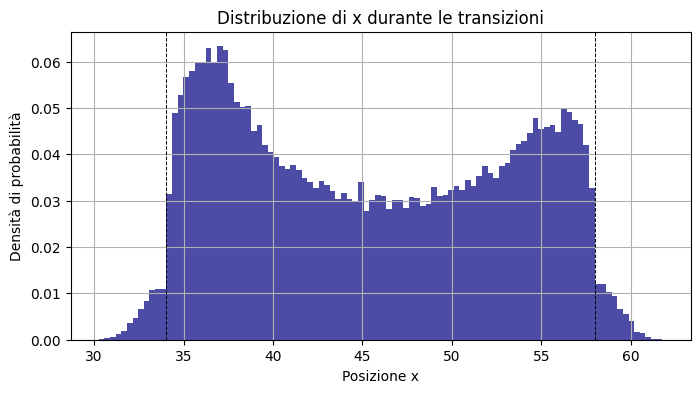

In [694]:
# Lista per raccogliere i tratti
x_transition_values = []

for _, row in df.iterrows():
    start = int(row['start_idx'])
    end = int(row['end_idx'])   # end è incluso
    x_transition_values.append(x_win[start:end])  # estrai tratto da x

x_all_transitions = np.concatenate(x_transition_values)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(x_all_transitions, bins=100, density=True, color='navy', alpha=0.7)
plt.axvline(x=34, linestyle="--", lw=0.7, c="black"); plt.axvline(x=58, linestyle="--", lw=0.7, c="black")

plt.xlabel("Posizione x")
plt.ylabel("Densità di probabilità")
plt.title("Distribuzione di x durante le transizioni")
plt.grid(True)
plt.show()


0.01599999999962165 0.01981832160395799
0.0161200000000008 0.019560250204438998
0.004000000000814907 0.004899999999906868


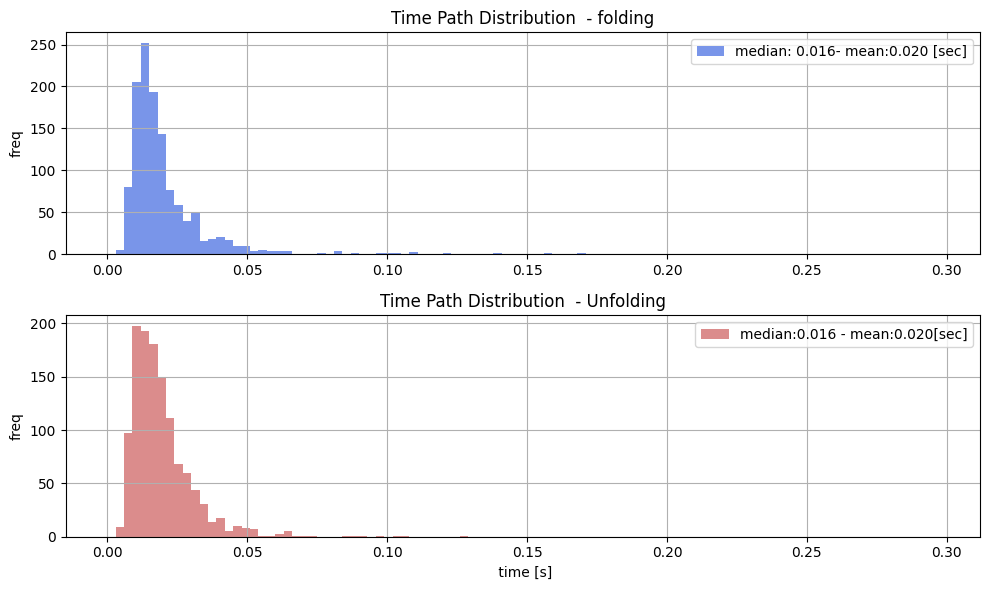

In [569]:

tp_fold = df[df["type"] == "folding"]["duration"]
tp_unf = df[df["type"] == "unfolding"]["duration"]
print(np.median(tp_fold), np.mean(tp_fold))
print(np.median(tp_unf), np.mean(tp_unf))
print(np.min(tp_fold), np.min(tp_unf))

plt.figure(figsize=(10, 6))

bins = np.arange(0, 0.3, 0.003)

plt.subplot(2, 1, 1)
plt.hist(tp_fold, bins=bins, alpha=0.7, color='royalblue', label=f"median: {np.median(tp_fold):.3f}- mean:{np.mean(tp_fold):.3f} [sec]")
plt.ylabel("freq"); 
plt.title("Time Path Distribution  - folding"); plt.legend(); plt.grid(True)
# plt.tick_params(axis='x', which='both', labelbottom=False)  # nasconde etichette x

plt.subplot(2, 1, 2)
plt.hist(tp_unf, bins=bins, alpha=0.7, color='indianred', label=f'median:{np.median(tp_unf):.3f} - mean:{np.mean(tp_unf):.3f}[sec]')
plt.xlabel(" time [s]"); plt.ylabel("freq"); plt.legend(); plt.grid(True); plt.title("Time Path Distribution  - Unfolding")

plt.tight_layout()
plt.show()

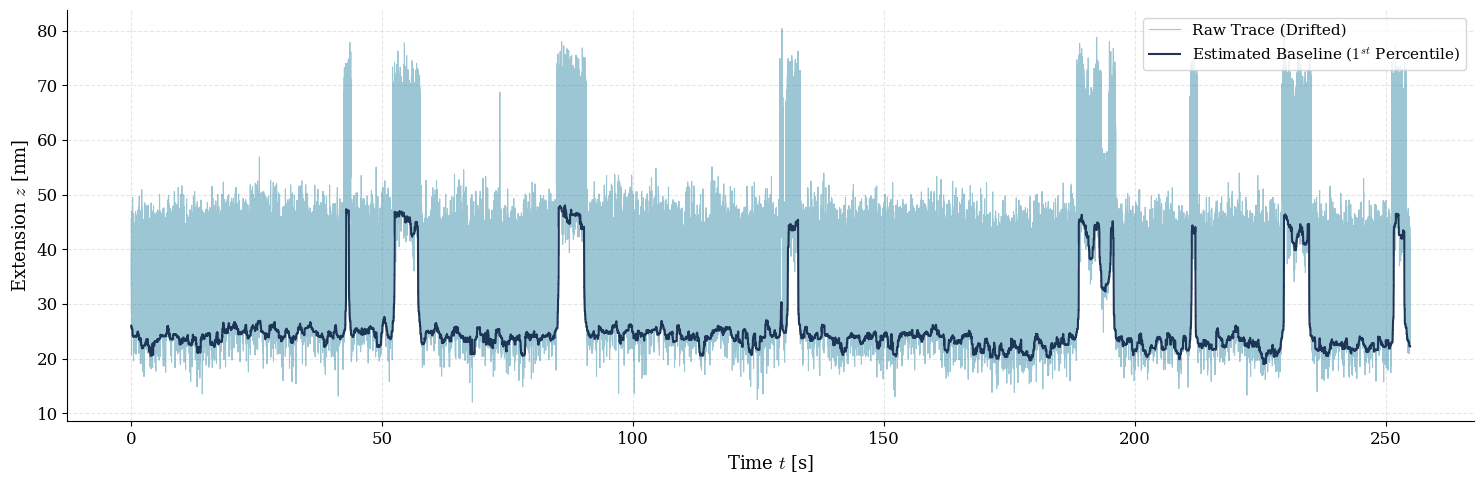

In [13]:
# DRIFT REMOVAL 

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

p, q = 0, 300_000
window = 1001
background = percentile_filter(x[p:q], percentile=1, size=window)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(t[p:q], x[p:q], color="#0A7294", lw=0.8, alpha=0.4, label='Raw Trace (Drifted)')
ax.plot(t[p:q], background,  color='#1D3557', lw=1.5, label='Estimated Baseline ($1^{st}$ Percentile)')
        
ax.set_xlabel('Time $t$ [s]')
ax.set_ylabel('Extension $z$ [nm]')

ax.legend(loc='upper right', frameon=True, shadow=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("FAK_percentile_drift.pdf", dpi=300)
plt.show()


<Figure size 2300x600 with 0 Axes>

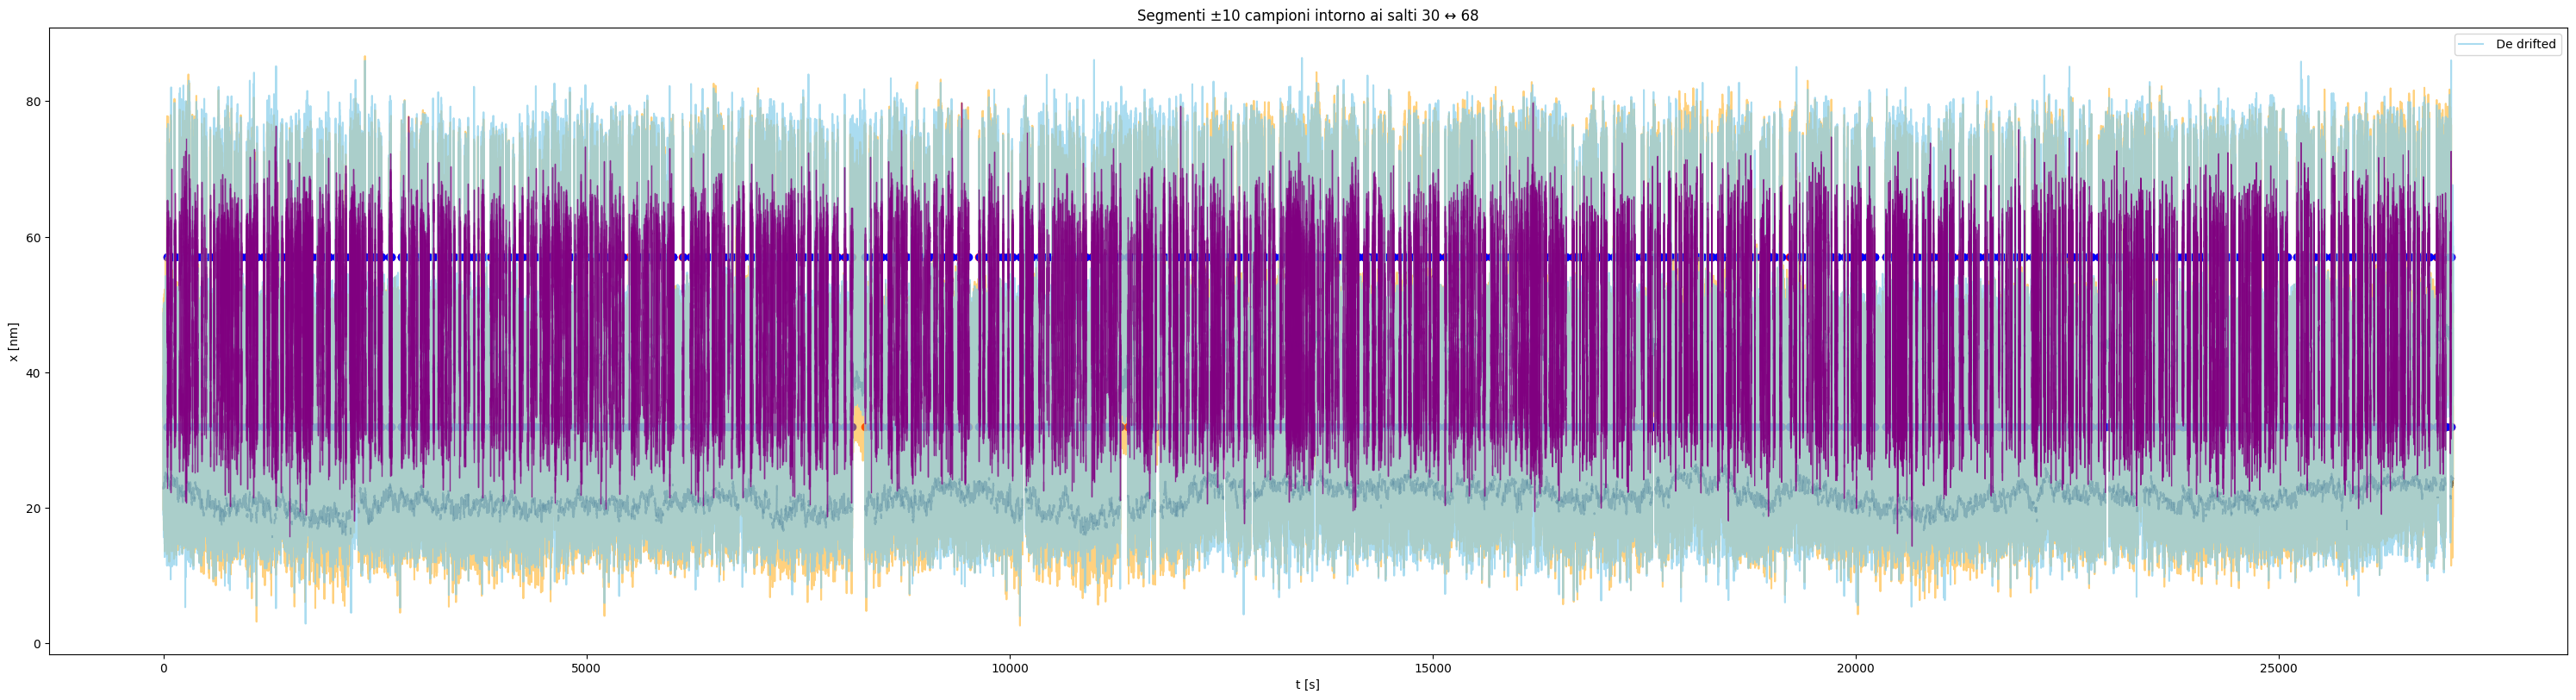

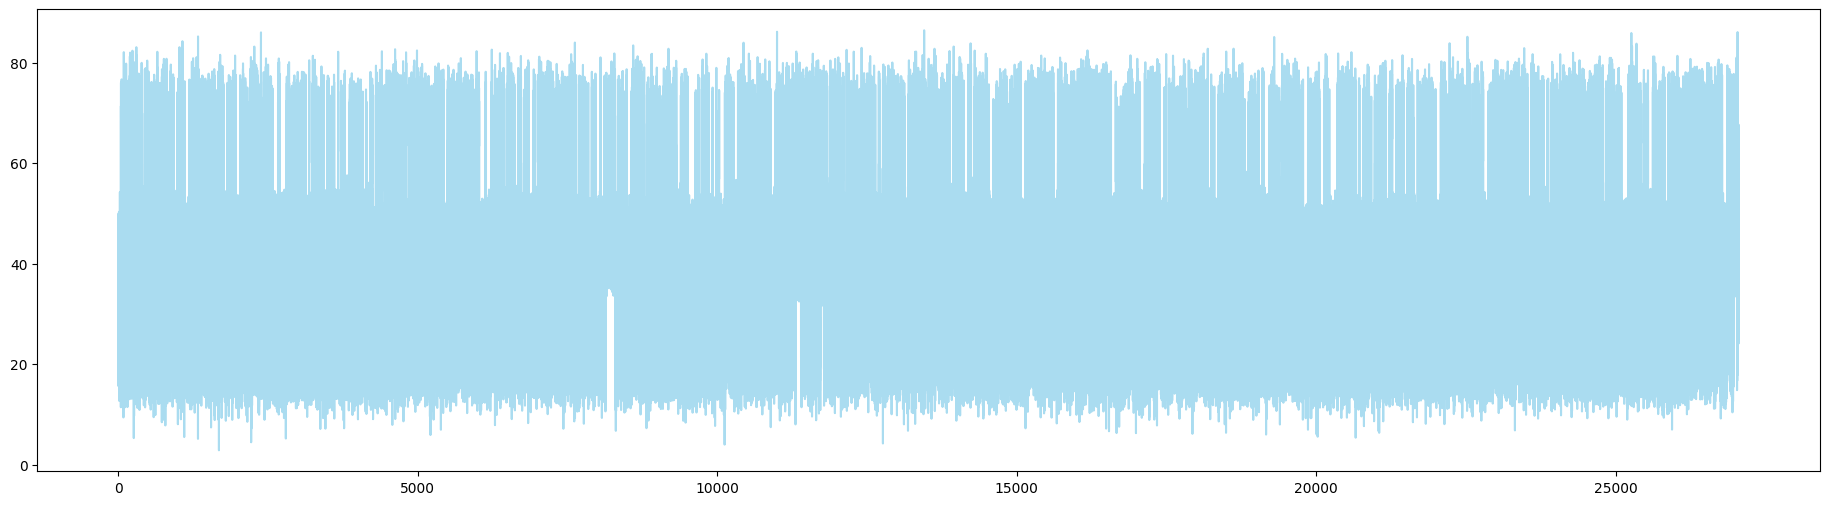

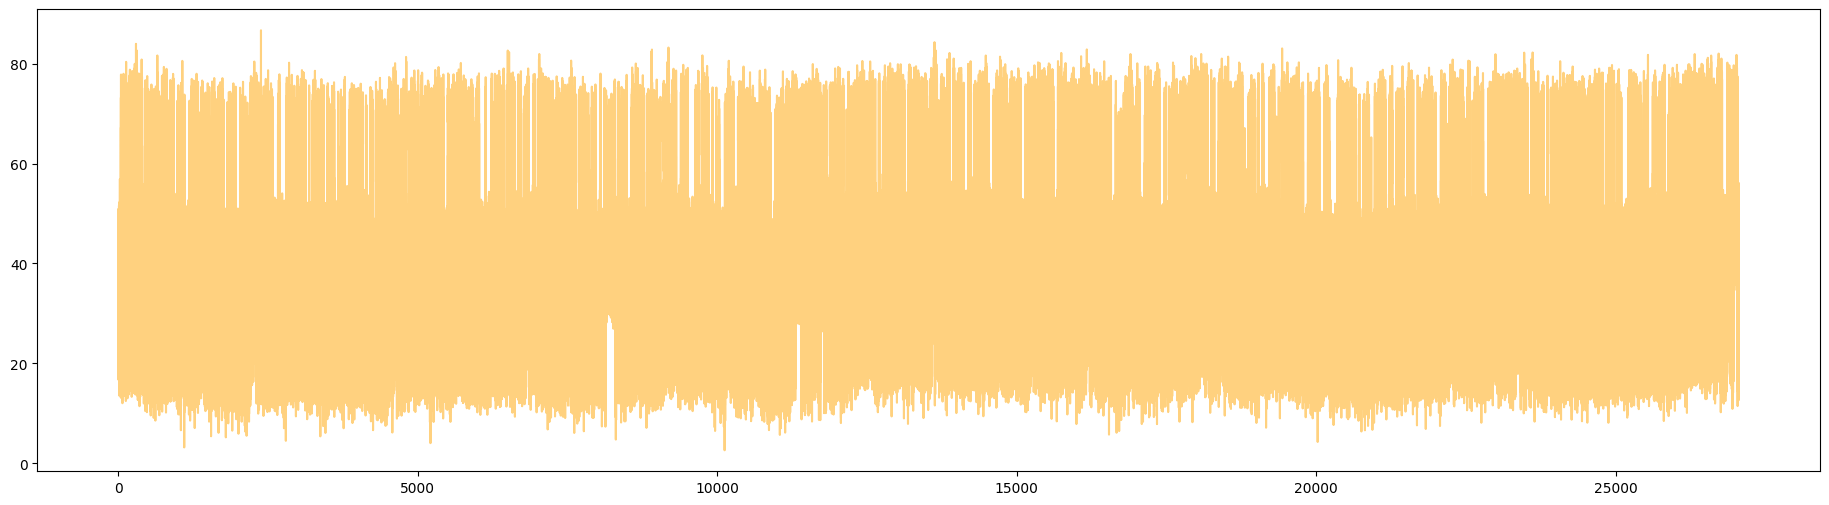

In [ ]:
plt.figure(figsize=(23,6))
window = 10_000

start= 0
fine  = int(len(t)*2/3)  # intervallo da visualizzare
t_win = t[start:fine]
x_win = x[start:fine]
mask_win  = mask[start:fine]

valid_idx   = np.where(~np.isnan(mask_win))[0]      # array di indici
valid_vals  = mask_win[valid_idx]                   # i loro valori (30/68)

change_pos  = np.where(valid_vals[1:] != valid_vals[:-1])[0] + 1

idx_from = valid_idx[change_pos - 1]    # ultimo indice del blocco corrente
idx_to   = valid_idx[change_pos]        # primo indice del blocco successivo


plt.figure(figsize=(30, 8))
plt.scatter(t_win[idx_to], mask_win[idx_to], c='red', s=35)
plt.scatter(t_win[idx_from], mask_win[idx_from], c='blue', s=35)
plt.plot(t_win, x[start:fine], color='orange', alpha=0.5)

x_detrend = np.full_like(x_win, np.nan)
start = 0 

# init flag  DRIFT REMOVAL 
is_up = False

for i_from, i_to in zip(idx_from, idx_to):
    # Plateau
    end = i_from
    seg = x_win[start:end+1]

    drift = percentile_filter(seg, percentile=1, size=window)
    t_drift = t_win[start:start+len(drift)]

    plt.plot(t_drift, drift , color="black", alpha=0.5)

    delta = np.median(seg) - drift
    x_detrend[start:end+1] = seg + delta

    # --- Traslazione per centro target ---
    if is_up:
        target = 57.5
    else:
        target = 34

    mean_segment = np.mean(x_detrend[start:end+1])
    x_detrend[start:end+1] -= (mean_segment - target)

    # Transition
    seg_trans = x_win[end+1:i_to]
    drift_trans = percentile_filter(seg_trans, percentile=1, size=100) + 11
    t_drift = t_win[start:start+len(drift_trans)]
    plt.plot(t_drift, drift_trans, color='black', alpha=0.5)

    delta_trans = np.median(seg_trans) - drift_trans
    x_detrend[end+1:i_to] = seg_trans + delta_trans

    # --- Traslazione per centro target anche su transizione ---
    if is_up:
        target = 58
    else:
        target = 34

    mean_segment_trans = np.mean(x_detrend[end+1:i_to])
    x_detrend[end+1:i_to] -= (mean_segment_trans - target)

    # Alterna UP/DOWN
    is_up = not is_up

    start = i_to
    
# ultimo blocco
if start < fine:
    seg = x_win[start:fine]

    drift = percentile_filter(seg, percentile=1, size=window) 
    t_drift = t_win[start:start+len(drift)]
    plt.plot(t_drift, drift, color='black', alpha=0.5)
    delta =  np.median(seg) -  drift
    x_detrend[start:fine] = seg + delta

#plot traiettoria detrended finale
plt.plot(t_win, x_detrend, label=" De drifted", c="skyblue",alpha=0.7)
plt.xlabel('t [s]')
plt.ylabel('x [nm]')
plt.legend()
plt.tight_layout()
for i_from, i_to in zip(idx_from, idx_to):      
    i_start = max(i_from - offset, 0)         
    i_end   = min(i_to   + offset, fine-1)     
    plt.plot(t_win[i_start:i_end+1], x_win[i_start:i_end+1], color='purple', lw=1, alpha=.8)      

plt.xlabel('t [s]'); plt.ylabel('x [nm]'); plt.title('Segmenti ±10 campioni intorno ai salti 30 ↔ 68')
plt.show()
np.save("x_detrend_FAK.npy", x_detrend)

plt.figure(figsize=(23,6))
plt.plot(t_win,  x_detrend, label=" De drifted", c="skyblue",alpha=0.7)
plt.show()

plt.figure(figsize=(23,6))
plt.plot(t_win, x_win, color='orange', alpha=0.5)



X values of histogram peaks: [33.71627868 57.2528726 ]
X values of histogram peaks (cleaned): [34.35426597 57.73626155]
X values of histogram peaks (cleaned): [34.08109357]


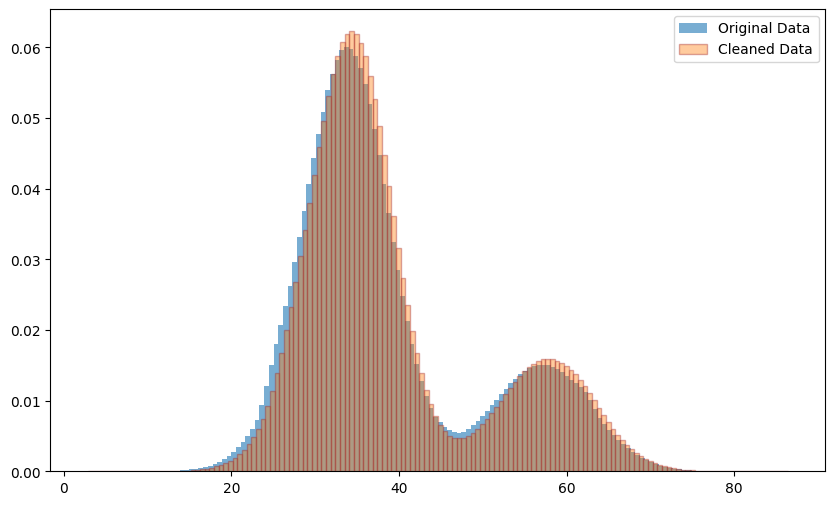

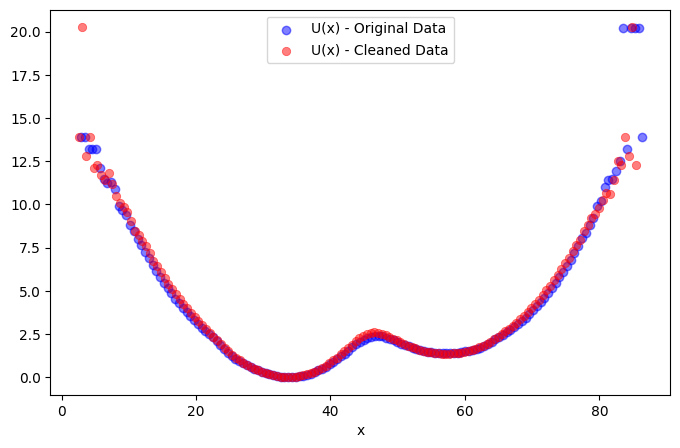

In [683]:
from scipy.signal import find_peaks
d_detrend = np.load("x_detrend_FAK.npy")
eb =150 
x_win = x[start:int((2/3)*len(x))]
plt.figure(figsize=(10, 6))

counts1, bin_edges = np.histogram(x_win, bins=eb, density=True)
bin_centers1 = (bin_edges[:-1] + bin_edges[1:]) / 2
peaks_indices, _ = find_peaks(counts1, height = 0.005)
peak_x_values = bin_centers1[peaks_indices]
print("X values of histogram peaks:", peak_x_values)

counts2, bin_edges2 = np.histogram(d_detrend, bins=eb, density=True)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
peaks_indices2, _ = find_peaks(counts2, height = 0.005)
peak_x_values2 = bin_centers2[peaks_indices2]
print("X values of histogram peaks (cleaned):", peak_x_values2)

counts3, bin_edges3 = np.histogram(x_smooth, bins=eb, density=True)
bin_centers3 = (bin_edges3[:-1] + bin_edges3[1:]) / 2
peaks_indices3, _ = find_peaks(counts3, height = 0.03)
peak_x_values3 = bin_centers3[peaks_indices3]
print("X values of histogram peaks (cleaned):", peak_x_values3)

plt.hist(x_win, bins=150, alpha=0.6, density=True, label="Original Data")
plt.hist(d_detrend, ec="brown", bins=150, density = True, alpha=0.4, label = "Cleaned Data") 
# plt.hist(x_smooth, ec="brown", bins=150, density = True, alpha=0.3, label = "x smooth ") 

plt.legend();plt.show()

U_1 = -np.log(counts1 + 1e-10)
U_2 = -np.log(counts2 + 1e-10)
U_1_shifted = U_1 - np.min(U_1)
U_2_shifted = U_2 - np.min(U_2)

x_peak1 = bin_centers1[peaks_indices[0]]
x_peak2 = bin_centers2[peaks_indices2[0]]

x_shift = x_peak1 - x_peak2
bin_centers2_aligned = bin_centers2 + x_shift

plt.figure(figsize=(8, 5))
plt.scatter(bin_centers1, U_1_shifted, color='blue', label="U(x) - Original Data", linewidth=1, alpha=0.5)
plt.scatter(bin_centers2_aligned, U_2_shifted, color='red', label="U(x) - Cleaned Data", linewidth=0.6, alpha = 0.5)
plt.xlabel('x'); 
plt.legend()

#print (len(x_win), len(d_detrend),len(U_2_shifted), len(x_smooth), len(bin_centers2_aligned))


U_max: 2.5969220728236726
left_min: 0.0
right_min: 1.3633076374465682
dG_fold: 1.2336144353771044
dG_unfold: 2.5969220728236726
beta: 0.24330900243309
gamma: 0.577
dG_fold: 1.2336144353771044
kappa_b: 0.10165742961354766
tp_mean_F: 0.01981832160395799
Numeratore arg log: 1.0689454242364194
Diffusion coeff _fold: 3019.434375609075 Diffusion coeff_unfold: 4597.858973878891


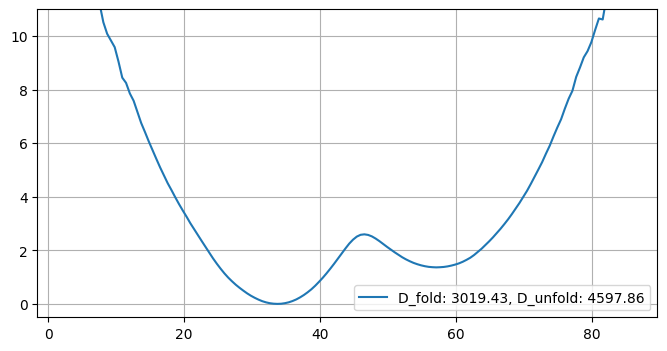

In [ ]:
def D_coeff(tp_mean_F, tp_mean_U, U, x, beta=1/4.11, gamma=0.577):
 
    from scipy.ndimage import gaussian_filter1d

    edge_fraction =0.27  #fraction of data i a
    N = len(U)
    start = int(N * edge_fraction)
    end = int(N * (1 - edge_fraction))
    mask = np.zeros_like(U, dtype=bool)
    mask[start:end] = True

    U_masked = U[mask]
    x_masked = x[mask]

    max_idx_masked = np.argmax(U_masked)
    max_idx = np.arange(len(U))[mask][max_idx_masked]  # mappa sull’indice originale
    U_max = U[max_idx]

    left_min = np.min(U[start:max_idx])
    right_min = np.min(U[max_idx:end])

    # left_min_idx = start + np.argmin(U[start:max_idx])
    # right_min_idx = max_idx + np.argmin(U[max_idx:end])
    
    dG_fold = U_max - right_min
    dG_unfold = U_max - left_min
    print("U_max:", U_max)
    print("left_min:", left_min)
    print("right_min:", right_min)
    print("dG_fold:", dG_fold)
    print("dG_unfold:", dG_unfold)

    # --- Curvatura barriera (kappa_b) ---
    U_smooth = gaussian_filter1d(U_masked, sigma=2.5)

    dx = x_masked[1] - x_masked[0]
    d2U_dx2 = np.gradient(np.gradient(U_smooth, dx), dx)

    max_idx_smooth = np.argmax(U_smooth)
    max_idx = np.arange(len(U))[mask][max_idx_smooth]  # coerente con curvatura

    kappa_b =np.abs(np.mean(d2U_dx2[max_idx_smooth - 1:max_idx_smooth + 2]))

    # --- Coefficienti D ---
    D_fold = np.log(2 * np.exp(gamma) * beta * dG_fold*4.11) / (beta * kappa_b * tp_mean_F)
    D_unfold = np.log(2 * np.exp(gamma) * beta * dG_unfold*4.11) / (beta * kappa_b * tp_mean_U)
    plt.figure(figsize=(8, 4))
    plt.plot(x, U, label=f"D_fold: {D_fold:.2f}, D_unfold: {D_unfold:.2f}"); plt.grid(True); plt.ylim(-0.5, 11)
    plt.legend()
    print("beta:", beta)
    print("gamma:", gamma)
    print("dG_fold:", dG_fold)
    print("kappa_b:", kappa_b)
    print("tp_mean_F:", tp_mean_F)
    print("Numeratore arg log:", 2 * np.exp(gamma) * beta * dG_fold)


    return ( D_fold, D_unfold, kappa_b, dG_fold, dG_unfold)


D_fold, D_unfold, kappa_b, dG_fold, dG_unfold = D_coeff(np.mean(tp_fold), np.mean(tp_unf),  U_2_shifted, bin_centers2_aligned)
print ("Diffusion coeff _fold:", D_fold, "Diffusion coeff_unfold:", D_unfold)

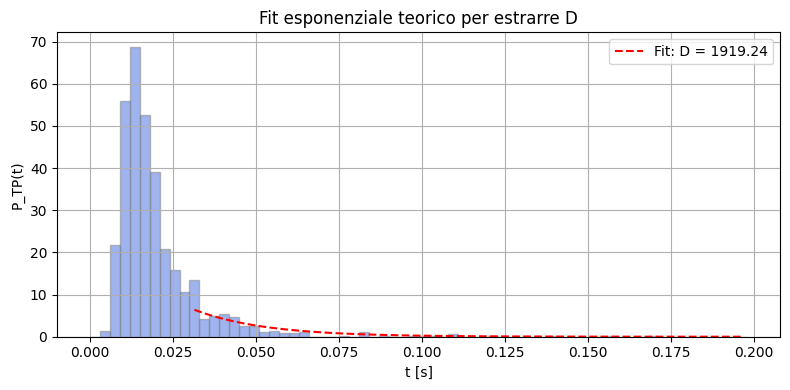

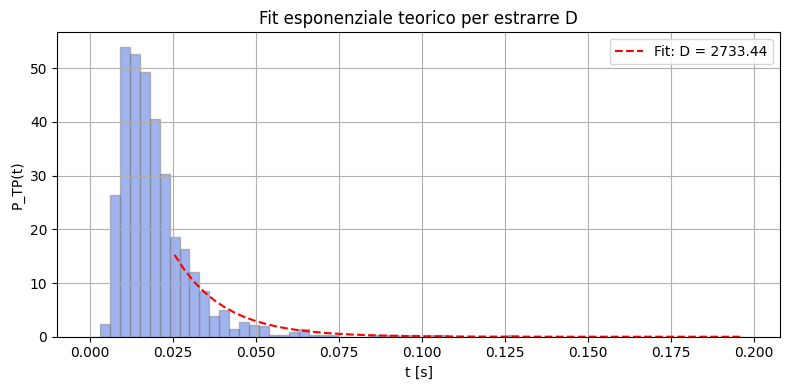

In [568]:
# RECOVERING DIFFUSION COEFF FROM EXPONENTIAL FIT of P t_TP
from scipy.optimize import curve_fit

tp_fold = tp_fold[tp_fold < 0.3]
tp_unf  = tp_unf[tp_unf < 0.3]

bins = np.arange(0, 0.2, 0.003)

def fit_diffusion_coefficient(tp, threshold, kappa_b, deltaG, beta=1/4.11, bins=bins):
    
    def exp_decay(t, D):
        omega_k = beta * D * np.abs(kappa_b)
        A = 2 * omega_k * beta * deltaG
        return A * np.exp(-omega_k * t)

    hist_vals, bin_edges = np.histogram(tp, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    fit_mask = bin_centers > threshold

    # popt, _ = curve_fit(exp_decay, bin_centers[fit_mask], hist_vals[fit_mask], p0=[1000])

    # D_fit = popt[0]
    from scipy.optimize import minimize_scalar

    def error(D):
        model = exp_decay(bin_centers[fit_mask], D)
        return np.sum((model - hist_vals[fit_mask])**2)

    res = minimize_scalar(error, bounds=(100, 5000), method='bounded')
    D_fit = res.x

    # Plot
    plt.figure(figsize=(8, 4))
    plt.hist(tp, bins=bins, density=True, ec="grey", alpha=0.5, color='royalblue')
    plt.plot(bin_centers[fit_mask], exp_decay(bin_centers[fit_mask], D_fit), 'r--',
             label=f'Fit: D = {D_fit:.2f}')
    plt.xlabel("t [s]")
    plt.ylabel("P_TP(t)")
    plt.title("Fit esponenziale teorico per estrarre D")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return D_fit

D_fold = fit_diffusion_coefficient(tp_fold, threshold=0.03, kappa_b=kappa_b, deltaG=dG_fold)
D_unfold = fit_diffusion_coefficient(tp_unf, threshold=0.025, kappa_b=kappa_b, deltaG=dG_unfold)


In [308]:
# DECONVOLUTION : beads +  handlers 

# beads std = 1.7nm
# handlers std = 1.92 nm 

def coth(x):
    return np.cosh(x)/ np.sinh(x)
kT = 4.11
lk = 4 #nm
Lc = 4 # nm: 4 proteins for handlers 
F  = 6 #pN
var_handlers = (4*Lc) * lk * (1- coth((F * lk)/kT)**2 + (kT/(F * lk))**2 );print ("var_handlers:", var_handlers)
var_beads = (1.78)**2 #nm
std_handlers = np.sqrt(var_handlers)
std_tot= np.sqrt( var_beads + var_handlers); print ("std_tot:", std_tot)



var_handlers: 1.8747313224685993
std_tot: 2.245691724718377


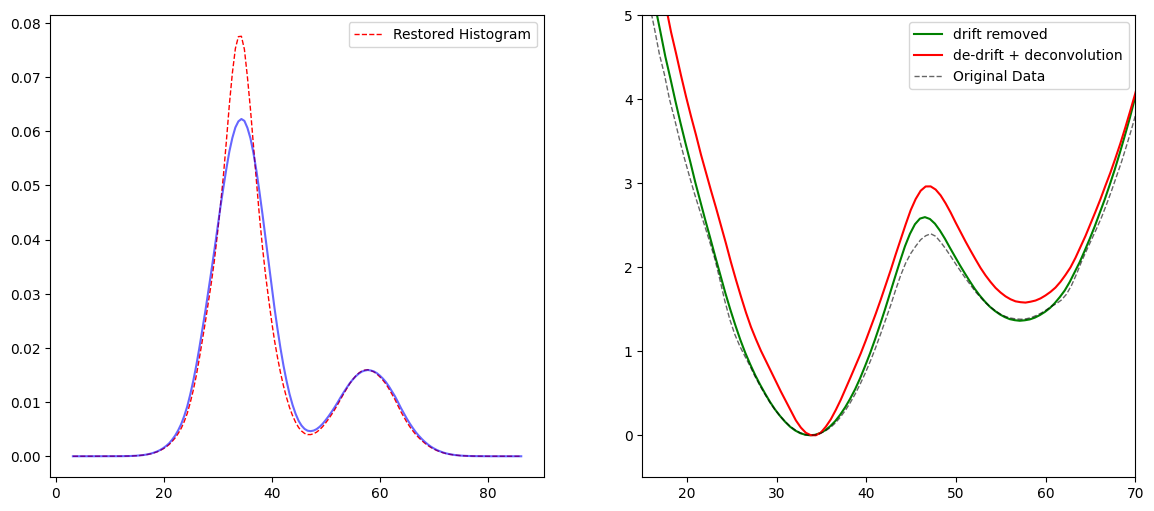

In [636]:
# DECONVOLUTION
# creo la PSF discreta gaussiana del linkers 
from scipy.fftpack import fftshift

sigma= std_tot
L = int(6*sigma+1)   # lunghezza del kernel, copre ±3σ
if L % 2 == 0:
    L += 1      

x = np.linspace(-3*sigma, 3*sigma, L)
kernel = np.exp(- x**2 / (2*sigma**2))
kernel /= kernel.sum()
kernel = fftshift(kernel) # allinea i picchi kernel vs dati

counts2, bin_edges2 = np.histogram(d_detrend, bins=150, density=True)

def jansson_deconvolution(observed, kernel, iterations=700, alpha=0.02):
    from scipy.signal import fftconvolve

    estimate = np.copy(observed).astype(np.float64)

    for _ in range(iterations):
        reconvolved = fftconvolve(estimate, kernel, mode='same')
        # usa una regolarizzazione minima per evitare annullamenti
        correction = observed - reconvolved
        update = alpha * correction * estimate
        estimate += update
        estimate[estimate < 0] = 0  # forza positività

    return estimate


restored = jansson_deconvolution(counts2, kernel,  iterations=1000, alpha=0.03)  #counts2: data w/out drift ## restored: no drift + deconvlution  
restored /= np.sum(restored) * (bin_centers2[1] - bin_centers2[0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(bin_centers2, restored, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_centers2, counts2, c="b", alpha =0.6)
plt.legend()

# recovering U(x)
U_obs  = U_2_shifted
U_dec = - np.log(restored + 1e-10)
shift = bin_centers2[np.argmin(U_obs)] - bin_centers2[np.argmin(U_dec)]
bin_centers2_shifted = bin_centers2 + shift
U_dec_shifted = U_dec - np.min(U_dec)


plt.subplot(1, 2, 2)
plt.plot(bin_centers2_aligned, U_2_shifted, c= "green", label = "drift removed")
plt.plot(bin_centers2_shifted, U_dec_shifted, c= "r", label="de-drift + deconvolution")
plt.plot(bin_centers1, U_1_shifted, linestyle="--", lw = 1, alpha = 0.6, c="black", label = "Original Data")
plt.ylim(-0.5, 5); plt.xlim(15, 70)
plt.legend()
plt.show()


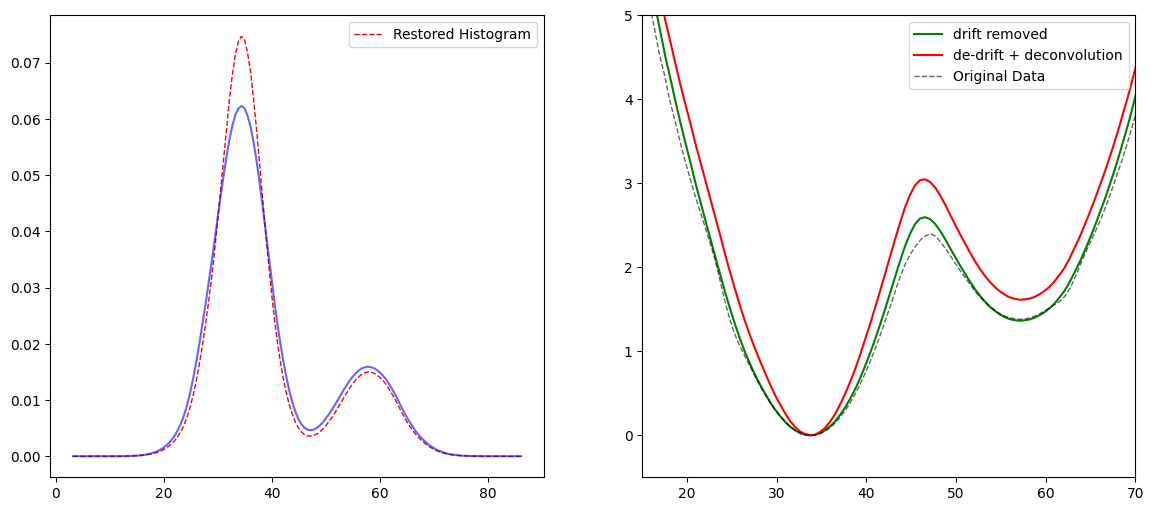

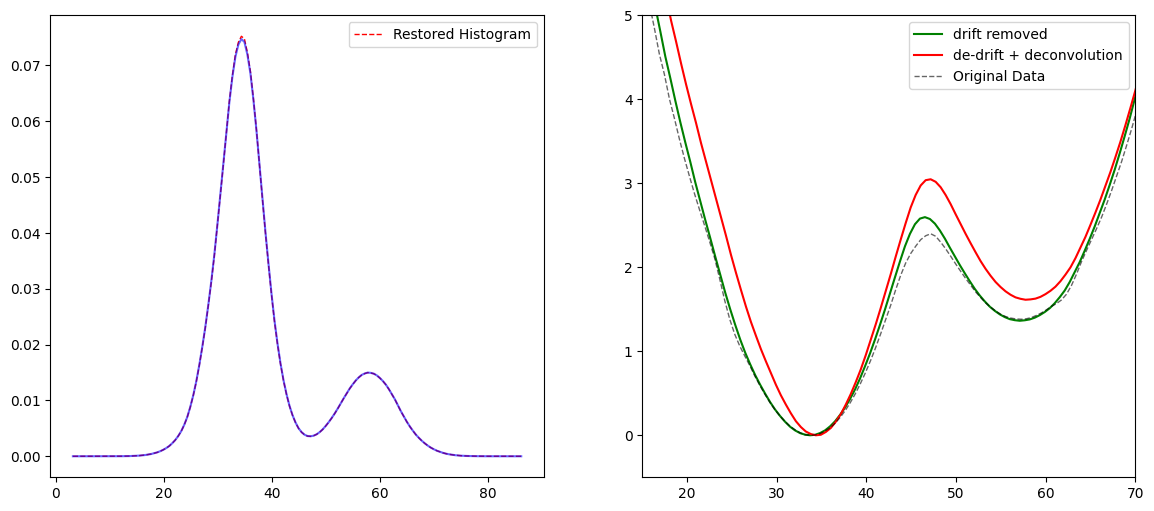

In [329]:
#check 

# BEADS DECONVOLUTION 
# counts2, bin_edges2 = np.histogram(d_detrend, bins=eb, density=True)


noise = np.loadtxt('beads_noise.txt', skiprows=1)  # Cambia con il tuo nome file
z_data = noise[:, 0]  # Colonna Z (nm)
t_data = noise[:, 1]  # Colonna Tempo (sec)

kernel, bins = np.histogram(z_data, bins=150, density=True)
kernel /= kernel.sum()
counts2, bin_edges2 = np.histogram(d_detrend, bins=150, density=True)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2

restored_beads = jansson_deconvolution(counts2, kernel,  iterations=700, alpha=0.015)  #counts2: data w/out drift ## restored: no drift + deconvlution  
restored_beads /= np.sum(restored_beads) * (bin_centers2[1] - bin_centers2[0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(bin_centers2, restored_beads, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_centers2, counts2, c="b", alpha =0.6)
plt.legend()

# recovering U(x)
U_obs  = U_2_shifted
U_dec = - np.log(restored + 1e-10)
shift = bin_centers2_aligned[np.argmin(U_obs)] - bin_centers2_aligned[np.argmin(U_dec)]
bin_centers2_shifted = bin_centers2_aligned + shift
U_dec_shifted = U_dec - np.min(U_dec)


plt.subplot(1, 2, 2)
plt.plot(bin_centers2_aligned, U_2_shifted, c= "green", label = "drift removed")
plt.plot(bin_centers2_shifted, U_dec_shifted, c= "r", label="de-drift + deconvolution")
plt.plot(bin_centers1, U_1_shifted, linestyle="--", lw = 1, alpha = 0.6, c="black", label = "Original Data")
plt.ylim(-0.5, 5); plt.xlim(15, 70)
plt.legend()
plt.show()



# BEADS + LINKRS DEC ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sigma= std_handlers
L = int(8*sigma+1)   # lunghezza del kernel, copre ±3σ
if L % 2 == 0:
    L += 1      

x = np.linspace(-4*sigma, 4*sigma, L)
kernel = np.exp(- x**2 / (2*sigma**2))
kernel /= kernel.sum()
# kernel = fftshift(kernel)

restored = jansson_deconvolution(restored_beads, kernel,  iterations=700, alpha=0.015)  #counts2: data w/out drift ## restored: no drift + deconvlution  
restored /= np.sum(restored) * (bin_centers2[1] - bin_centers2[0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(bin_centers2, restored, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_centers2, restored_beads, c="b", alpha =0.6)
plt.legend()

# recovering U(x)
U_obs  = U_2_shifted
U_dec = - np.log(restored + 1e-10)
shift = bin_centers2[np.argmin(U_obs)] - bin_centers2[np.argmin(U_dec)]
bin_centers2_shifted = bin_centers2 + shift
U_dec_shifted = U_dec - np.min(U_dec)


plt.subplot(1, 2, 2)
plt.plot(bin_centers2_aligned, U_2_shifted, c= "green", label = "drift removed")
plt.plot(bin_centers2_shifted, U_dec_shifted, c= "r", label="de-drift + deconvolution")
plt.plot(bin_centers1, U_1_shifted, linestyle="--", lw = 1, alpha = 0.6, c="black", label = "Original Data")
plt.ylim(-0.5, 5); plt.xlim(15, 70)
plt.legend()
plt.show()


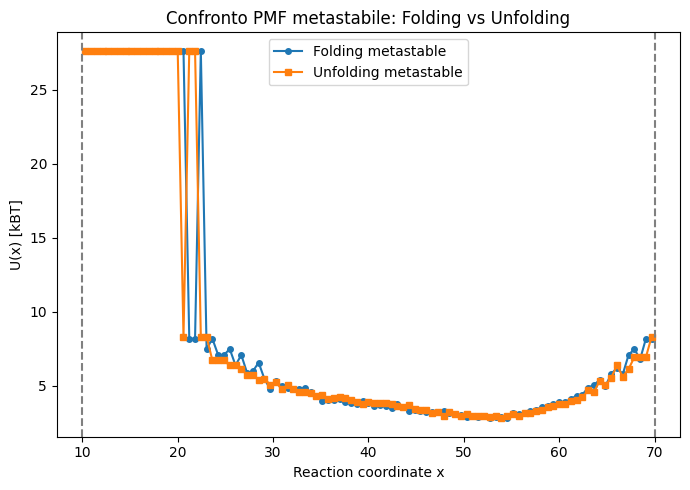

In [483]:

# probabilità condizionata : dato uno x nella zona metastabile 
# 1) Parametri di filtro
t_min, t_max = 0.04, 0.07    # l'intervallo di durata che definisce il metastabile
x_min, x_max = 10, 70.0    # i confini spaziali del pozzo intermedio
n_bins = 100                 # numero di bin per l'istogramma

# 3) Seleziona solo le transizioni “metastabili”
def compute_U_meta(direction):
    # Filtra transizioni
    df_meta = df[
        (df["type"] == direction) &
        (df["duration"].between(t_min, t_max))
    ].copy()
    df_meta["n_idx"] = df_meta["end_idx"] - df_meta["start_idx"] + 1

    # Maschera temporale
    mask = np.zeros(len(x), dtype=bool)
    for i0, i1 in zip(df_meta["start_idx"], df_meta["end_idx"]):
        mask[int(i0):int(i1)+1] = True

    # Estrai x e applica filtro spaziale
    x_meta = x[mask]
    x_meta = x_meta[(x_meta >= x_min) & (x_meta <= x_max)]

    # Istogramma e calcolo U(x)
    bins = np.linspace(x_min, x_max, n_bins)
    counts, edges = np.histogram(x_meta, bins=bins, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])
    U = -np.log(counts + 1e-12)

    return centers, U

# Calcola per folding e unfolding
cent_folding, U_folding = compute_U_meta("folding")
cent_unfolding, U_unfolding = compute_U_meta("unfolding")

# Plot
plt.figure(figsize=(7,5))
plt.plot(cent_folding, U_folding, '-o', ms=4, label="Folding metastable")
plt.plot(cent_unfolding, U_unfolding, '-s', ms=4, label="Unfolding metastable")


# Linee di riferimento
for x0 in (x_min, x_max):
    plt.axvline(x0, color='gray', ls='--')

plt.xlabel("Reaction coordinate x")
plt.ylabel("U(x) [kBT]")
plt.title("Confronto PMF metastabile: Folding vs Unfolding")
plt.legend()
plt.tight_layout()
plt.show()


In [616]:
# MFPT rate : Talin vs FAK

# use my own deirved D vs canonic 3000nm2/s

from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

def mfpt_analysis(x, U, D, prominence=0.4, width=20, distance=20):

    mask = np.isfinite(U)  # True dove G1 è un numero valido
    bin_c_clean = x[mask]
    U_clean = U[mask]

    U_interp = interp1d(bin_c_clean, U_clean, kind='cubic', fill_value='extrapolate')

    # 3) Trova minima e barriera
    min_idx, _ = find_peaks(-U, prominence=prominence, width=width, distance=distance)
    max_idx, _ = find_peaks(U,  prominence=prominence, width=width, distance=distance)

    x_folded   = x[min_idx[0]]
    x_unfolded = x[min_idx[1]]
    x_barrier  = x[max_idx]

    print("Minima idx:", min_idx, "→", x_folded, x_unfolded)
    print("Barriera idx:", max_idx, "→", x_barrier)
    print("U(minima):", U_interp([x_folded, x_unfolded]),
          "U(barriera):", U_interp(x_barrier))

#---------------------------------------------------
    def mfpt(U_interp,x, x_a, x_b, D):
        def inner_integral(y):
            result, _ = quad(lambda z: np.exp(-(U_interp(z) - U_interp(x_a))), x_a, y, limit=1000)
            return result

        def outer_integral():
            result, _ = quad(lambda y: np.exp(U_interp(y) - U_interp(x_a)) * inner_integral(y), x, x_b, limit=1000)
            return result

        return outer_integral() / D


    
    print(f"x_folded: {x_folded}, x_unfolded: {x_unfolded}, x_barrier: {x_barrier}")
    print(f"U(x_folded): {U_interp(x_folded)}, U(x_unfolded): {U_interp(x_unfolded)}, U(x_barrier): {U_interp(x_barrier)}")

    mfpt_fold = mfpt(U_interp, x_folded, x_folded - 4.5, x_unfolded, D=D)
    mfpt_unfold = mfpt(U_interp, x_unfolded, x_unfolded + 4.5, x_folded, D=D)

    rate_unfolding   = 1 / mfpt_fold   if mfpt_fold   > 0 else np.nan
    rate_folding = 1 / mfpt_unfold if mfpt_unfold > 0 else np.nan

    print(f"Rate Folding:   {rate_folding:.4e} s⁻¹")
    print(f"Rate Unfolding: {rate_unfolding:.4e} s⁻¹")

    plt.figure(figsize=(8,5))
    plt.plot(bin_c_clean, U_interp(bin_c_clean),  label='U(x)', linewidth=2)
    plt.scatter([x_folded, x_unfolded], [U_interp(x_folded), U_interp(x_unfolded)],
                c='green', label='Minima')
    plt.scatter([x_barrier],[U_interp(x_barrier)], c='red', label='Barriera')
    plt.xlabel('x')
    plt.ylabel('U(x) [kT]')
    plt.legend()
    plt.grid(True)
    plt.show()

    return rate_folding, rate_unfolding


Minima idx: [56 98] → 34.35426597250962 57.73626154730324
Barriera idx: [79] → [47.15869212]
U(minima): [0.         1.57963993] U(barriera): [2.96303993]
x_folded: 34.35426597250962, x_unfolded: 57.73626154730324, x_barrier: [47.15869212]
U(x_folded): 0.0, U(x_unfolded): 1.5796399343966394, U(x_barrier): [2.96303993]
Rate Folding:   5.6478e+00 s⁻¹
Rate Unfolding: 1.5013e+00 s⁻¹


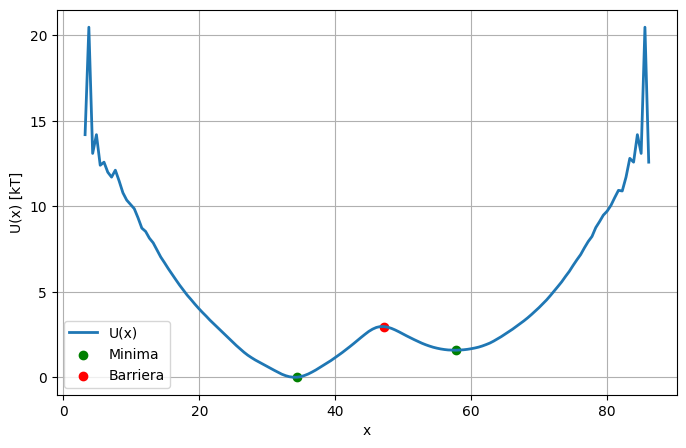

(5.6478377127098645, 1.5013298556332564)

In [638]:
# deconvoluted de drifted landscape alpha = 0.02 / D via exponential fit 
D = np.mean([1919.24, 2733.44])
#D = np.mean([3019.43, 4597.86])
mfpt_analysis(bin_centers2_shifted, U_dec_shifted, D = D, prominence=0.2, width=10, distance=10) 


Minima idx: [56 98] → 34.35426597250962 57.73626154730324
Barriera idx: [79] → [47.15869212]
U(minima): [-8.67361738e-19  1.52283657e+00] U(barriera): [2.8657802]
x_folded: 34.35426597250962, x_unfolded: 57.73626154730324, x_barrier: [47.15869212]
U(x_folded): -8.673617379884035e-19, U(x_unfolded): 1.5228365722048218, U(x_barrier): [2.8657802]
Rate Folding:   9.5020e+00 s⁻¹
Rate Unfolding: 2.5440e+00 s⁻¹


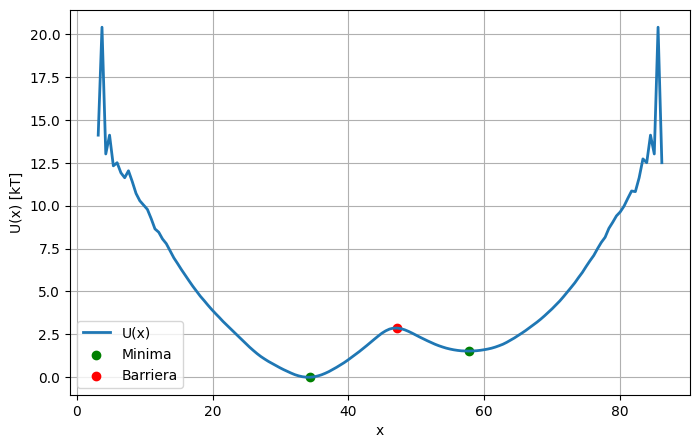

(9.501969543156623, 2.5440232081932814)

In [623]:
# alpha = 0.03
#D = np.mean([1919.24, 2733.44])
D = np.mean([3019.43, 4597.86])
mfpt_analysis(bin_centers2_shifted, U_dec_shifted, D = D, prominence=0.2, width=10, distance=10) 

Minima idx: [55 97] → 33.71627868 57.2528726
Barriera idx: [79] → [47.16576092]
U(minima): [5.42101086e-20 1.38113522e+00] U(barriera): [2.39876642]
x_folded: 33.71627868, x_unfolded: 57.2528726, x_barrier: [47.16576092]
U(x_folded): 5.421010862427522e-20, U(x_unfolded): 1.3811352189158392, U(x_barrier): [2.39876642]
Rate Folding:   1.1145e+01 s⁻¹
Rate Unfolding: 3.1167e+00 s⁻¹


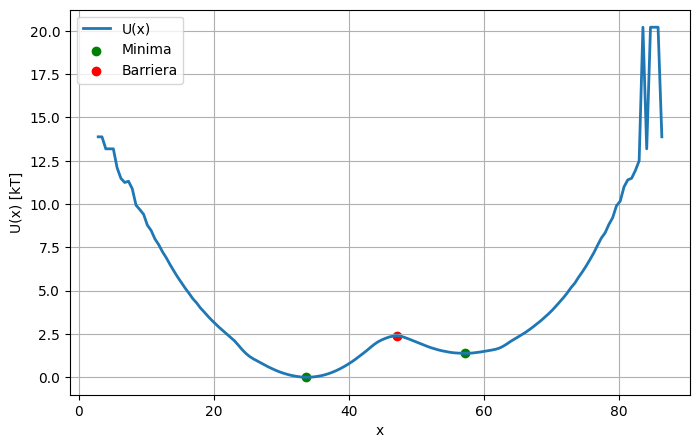

(11.144703290259516, 3.1167363923022906)

In [624]:
# Raw data landscape / D via expoenential fit 
#D = np.mean([1919.24, 2733.44])
D = np.mean([3019.43, 4597.86])
mfpt_analysis(bin_centers1, U_1_shifted, D = D, prominence=0.2, width=10, distance=10) 

Minima idx: [56 98] → 34.35426597250962 57.73626154730324
Barriera idx: [79] → [47.15869212]
U(minima): [0.         1.47667764] U(barriera): [2.78569131]
x_folded: 34.35426597250962, x_unfolded: 57.73626154730324, x_barrier: [47.15869212]
U(x_folded): 0.0, U(x_unfolded): 1.4766776382064788, U(x_barrier): [2.78569131]
Rate Folding:   7.6516e+01 s⁻¹
Rate Unfolding: 2.0705e+01 s⁻¹


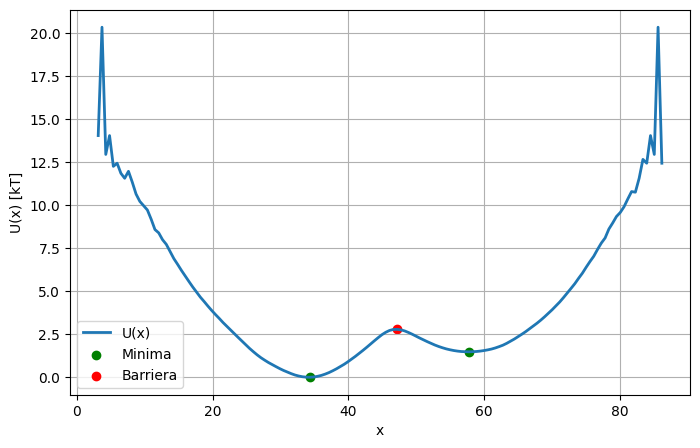

(76.51574939157285, 20.705002701930145)

In [ ]:
# deconvoluted de drifted landscape / D = 3000
mfpt_analysis(bin_centers2_shifted, U_dec_shifted, D = 3000, prominence=0.2, width=10, distance=10) 

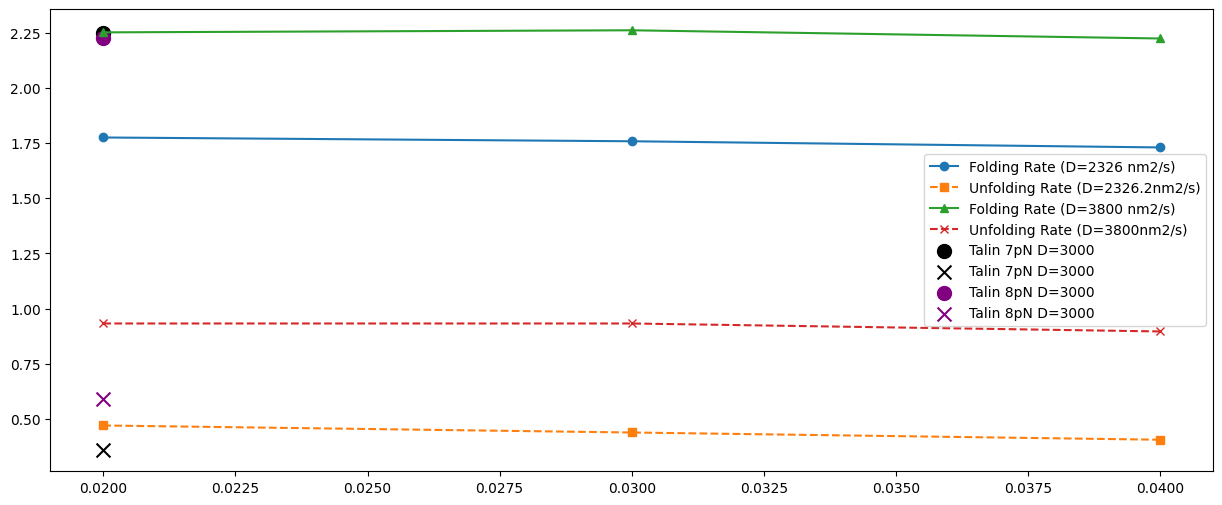

In [656]:
alpha = [0.02, 0.03, 0.04]
rate_fold_D_exp = np.log([5.9, 5.8, 5.64])
rate_unfold_D_exp = np.log([1.6, 1.55, 1.5])

rate_fold_Dk = np.log([9.5, 9.59, 9.24])
rate_unfold_Dk=np.log([2.54, 2.54, 2.45])

plt.figure(figsize=(15, 6))
plt.plot(alpha, rate_fold_D_exp, marker='o', label='Folding Rate (D=2326 nm2/s)')
plt.plot(alpha, rate_unfold_D_exp, marker='s', label='Unfolding Rate (D=2326.2nm2/s)', linestyle ="--")
plt.plot(alpha, rate_fold_Dk, marker='^', label='Folding Rate (D=3800 nm2/s)')
plt.plot(alpha, rate_unfold_Dk, marker='x', label='Unfolding Rate (D=3800nm2/s)', linestyle ="--")
plt.scatter(0.02, np.log(9.48), s =100, c ="black", label = "Talin 7pN D=3000")
plt.scatter(0.02, np.log(1.43), s =100, c ="black", label = "Talin 7pN D=3000", marker="x")
plt.scatter(0.02, np.log(9.24), s =100, c ="purple", label = "Talin 8pN D=3000")
plt.scatter(0.02, np.log(1.8), s =100, c ="purple", label = "Talin 8pN D=3000", marker="x")
plt.legend()